In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

clinical_gex = pl.read_csv(f"../dataset/created/clinical_gex.csv")
clinical_gex

patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_month,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,dabrafenib,trametinib,vemurafenib,C195W,K601I,MND,R558Q,V600E,V600K,V600R,sample_id,source_right,pfs_label_right,MAGEA4,VCX3A,SV2B,MAGEA1,VCX2,BAIAP2L1,MAGEA10,CTAG2,CSAG2,CKMT1A,GNB5,…,DSCR8,C1QTNF9B,PPP1R3F,SDS,NUDT15,DENND5A,RAB11FIP1,ZNF395,TUBB3,TIGD6,AIF1L,ZNF229,LOC728554,TCFL5,PLAG1,TDH,VLDLR,ARHGAP28,OPHN1,RAD9A,FBXO48,TIAM1,GAP43,SURF6,MYOM2,CSAG1,CRYZ,LRFN2,MAGEA3,ABHD6,ARL10,DNHD1,PPIH,TFF3,PBK,FGF13,EXOSC3
str,str,i64,str,str,str,f64,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""YR_3053""","""male""",26,"""IV""","""M1B""","""elevated""",2.9,null,"""no""","""no""","""Yan et al.""",0,0,0,0,1,0,0,0,0,1,0,0,"""03660555B""","""Yan et al.""",0,4.352461,5.136899,4.68535,5.189127,5.30349,5.596766,4.657524,4.691475,4.815777,4.838144,5.511944,…,4.998998,4.598046,5.108318,4.741692,5.706387,6.517363,6.42378,6.5609,7.447856,4.632723,7.46384,4.205274,6.618716,6.006904,4.923222,3.883233,6.47874,4.627395,4.733492,5.385977,4.278327,4.794856,4.396161,6.479374,4.909547,7.020221,6.370399,4.00089,6.28746,5.764514,4.015359,4.416253,6.739738,5.003677,5.890783,5.189148,6.328
"""YR_3708""","""female""",58,"""IV""","""M1A""","""normal""",13.2,null,"""no""","""no""","""Yan et al.""",2,0,0,0,1,0,0,0,0,1,0,0,"""03660598B""","""Yan et al.""",2,6.570555,5.158157,4.697329,5.436335,5.282412,5.724922,4.673865,4.685542,5.002026,4.823392,5.520698,…,4.716858,4.614575,5.155613,4.738068,5.780937,6.69161,6.832015,6.412755,7.987326,4.711399,7.580741,4.09871,6.617454,6.15428,4.826822,3.883233,7.394174,4.58168,4.655143,5.489278,4.252246,4.676489,4.327306,6.693238,5.153024,7.247881,7.073525,4.00089,6.865694,6.033802,4.041276,4.613856,6.862496,5.049185,6.070983,5.128801,6.472128
"""YR_3705""","""male""",45,"""IV""","""M1A""","""normal""",17.4,null,"""no""","""no""","""Yan et al.""",2,0,0,0,1,0,0,0,0,1,0,0,"""03660602B""","""Yan et al.""",2,5.121619,5.6063,4.679799,4.94371,5.286963,5.540081,4.605398,4.685542,4.773099,4.822577,5.648834,…,5.567704,4.596732,5.128214,4.739978,5.847631,6.665335,6.35116,6.302636,6.596889,4.659869,7.471207,4.131287,6.622418,6.042509,4.929768,3.883233,5.551979,4.674432,4.639448,5.387564,4.281811,4.930001,4.372685,6.414757,4.831788,6.119016,6.675007,4.00089,5.629798,5.75064,4.011071,4.651746,6.769417,5.008392,5.894473,5.628744,6.725773
"""YR_1106""","""male""",48,"""IIIC""",null,"""normal""",1.4,null,"""no""","""no""","""Yan et al.""",0,1,0,0,1,0,0,0,0,1,0,0,"""04240076F""","""Yan et al.""",0,4.330612,5.12214,4.706186,4.544665,5.274799,5.671164,4.600569,4.695826,4.710835,4.824523,5.517643,…,4.717225,4.592083,5.105555,4.8011,5.686645,7.041298,6.355911,6.347053,7.068522,4.654083,7.454041,4.03427,6.614395,5.996841,4.839008,3.884491,5.007876,5.19275,4.509781,5.330479,4.249143,4.624107,4.32751,6.445733,4.836819,5.138535,6.479098,4.00089,4.951684,5.756891,4.040749,4.414295,6.52239,5.060871,5.74085,5.146984,6.30193
"""YR_1110""","""male""",33,"""IV""","""M1C""","""normal""",1.4,null,"""no""","""no""","""Yan et al.""",0,1,0,0,1,0,0,0,0,1,0,0,"""04240106F""","""Yan et al.""",0,4.330576,5.133844,4.745812,4.86601,5.278892,5.681413,4.888742,4.685542,4.86269,4.821645,5.376002,…,6.675318,4.600331,5.152749,4.811936,5.735904,7.155997,6.349381,6.461865,7.427956,4.675325,8.142162,4.262057,6.616135,6.289311,5.032443,3.883233,6.599731,4.782657,4.79579,5.453684,4.234814,4.724571,4.317788,6.498996,4.887051,6.686782,6.614028,4.00089,6.26734,5.995879,4.037211,4.800719,6.959851,5.064195,5.65068,5.206566,6.41538
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""HL_Shi-35""","""male""",61,"""IV""","

## 1. Dataset Overview

In [2]:
# Identify clinical vs gene expression columns
# Clinical columns are the first 25 (up to pfs_label_right), GEX starts after
CLINICAL_COLS = ["patientID", "sex", "age", "AJCC_stage", "M_stage", "LDH",
                 "brain_metastasis", "immunotherapy_treatment", "pre_MAPKi_treatment",
                 "source", "pfs_label", "cobimetinib", "dabrafenib", "trametinib",
                 "vemurafenib", "C195W", "K601I", "MND", "R558Q", "V600E", "V600K",
                 "V600R", "sample_id", "source_right", "pfs_label_right", "PFS_month"]
GEX_COLS = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print(f"Shape: {clinical_gex.shape}")
print(f"Clinical columns : {len(CLINICAL_COLS)}")
print(f"Gene expression columns: {len(GEX_COLS)}")
print(f"\nDtypes:\n{clinical_gex.dtypes}")
print(f"\nFirst GEX genes: {GEX_COLS[:10]}")
print(f"Last  GEX genes: {GEX_COLS[-10:]}")

Shape: (137, 148)
Clinical columns : 26
Gene expression columns: 122

Dtypes:
[String, String, Int64, String, String, String, Float64, String, String, String, String, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, String, String, Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float6

In [3]:
from sklearn.decomposition import PCA

X = clinical_gex[GEX_COLS]
y = clinical_gex['pfs_label']

pca = PCA(n_components=3)
X_pca = pca.fit_transform(clinical_gex[GEX_COLS])
print(X_pca[:2])


[[ 0.13900981  0.81254887 -0.28095452]
 [ 0.57240829  1.03319558 -0.88726324]]


In [4]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.36268292 0.09012778 0.05920345]
Cumulative: [0.36268292 0.4528107  0.51201415]


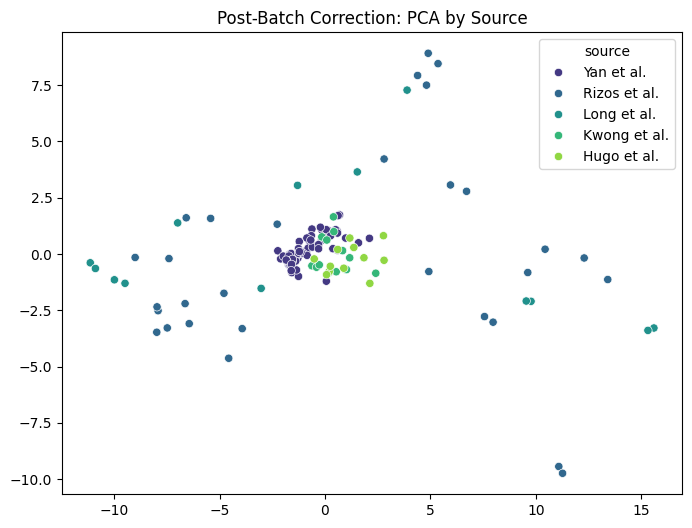

In [5]:
import seaborn as sns

# Plot PC1 vs PC2 colored by Source
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clinical_gex['source'], palette='viridis')
plt.title("Post-Batch Correction: PCA by Source")
plt.show()

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


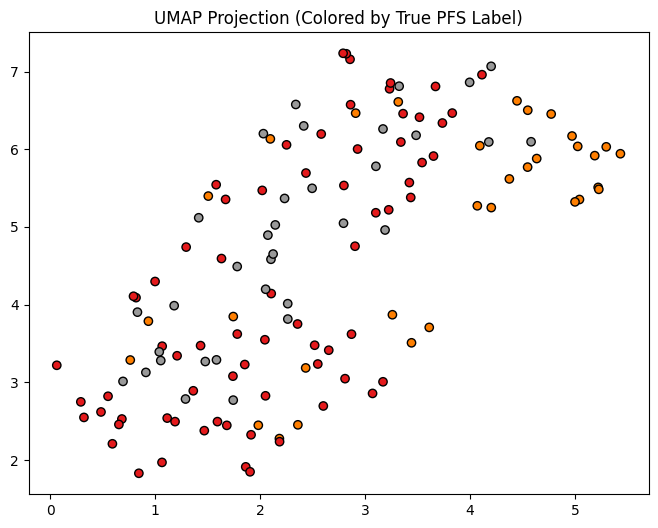

In [6]:
import umap

# Use the same top 1000 variable genes (batch corrected)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X) # Use your corrected data here

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Set1', edgecolor='k')
plt.title("UMAP Projection (Colored by True PFS Label)")
plt.show()

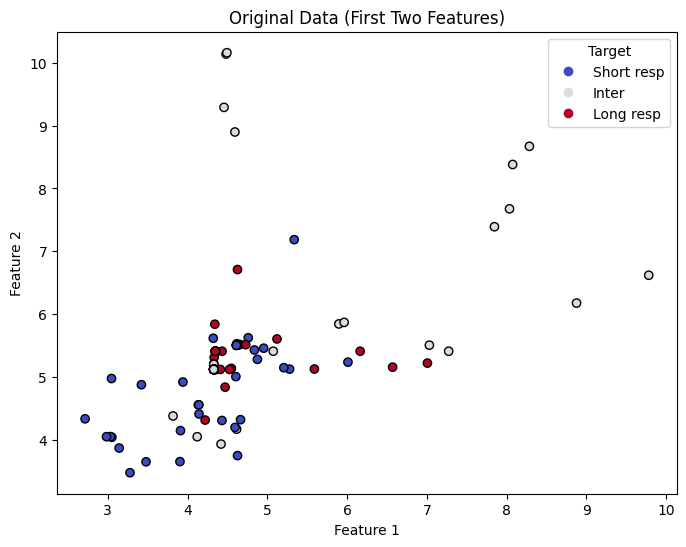

In [7]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data (First Two Features)")
class_names = ["Short resp", "Inter", "Long resp"]
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Target")
plt.show()


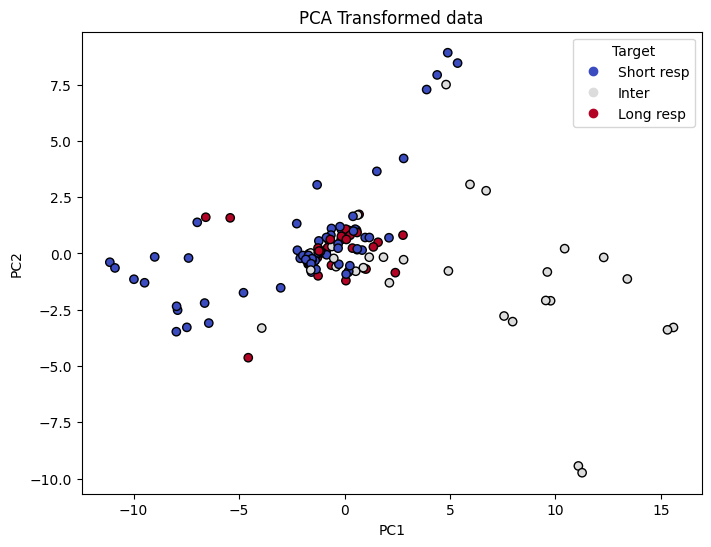

In [8]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Transformed data")
class_names = ["Short resp", "Inter", "Long resp"]
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Target")
plt.show()


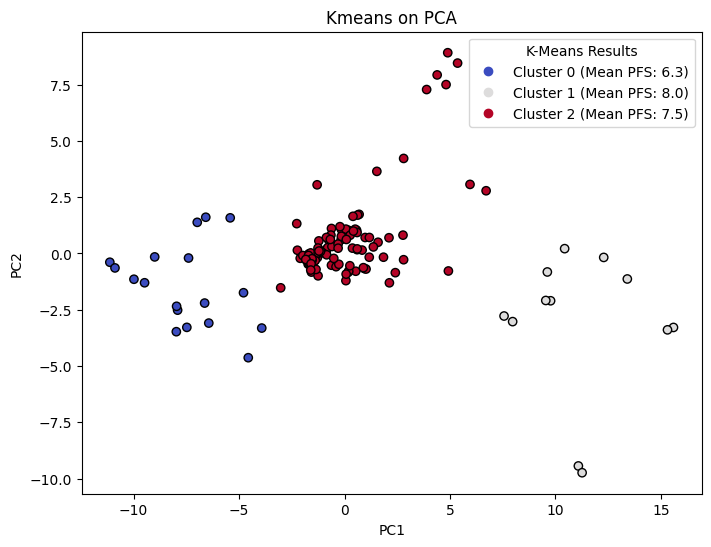

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42).fit(X_pca)
y_kmeans = kmeans.labels_

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='coolwarm', edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Kmeans on PCA")
# Use the actual cluster numbers in the legend to stay objective
plt.legend(handles=scatter.legend_elements()[0], 
           labels=["Cluster 0 (Mean PFS: 6.3)", 
                   "Cluster 1 (Mean PFS: 8.0)", 
                   "Cluster 2 (Mean PFS: 7.5)"], 
           title="K-Means Results")
plt.show()

In [10]:
import polars as pl

results = pl.DataFrame({
    'Cluster': y_kmeans,
    'PFS_Month': clinical_gex['PFS_month'], # Removed .values
    'True_Label': y                         # Removed .values
})

with pl.Config(tbl_rows=-1):  # -1 means "all rows"
    # Sorting in Polars
    print(results.sort(['Cluster', 'PFS_Month']))

# Summary stats in Polars
cluster_summary = results.group_by('Cluster').agg([
    pl.col('PFS_Month').mean().alias('mean'),
    pl.col('PFS_Month').median().alias('median'),
    pl.col('PFS_Month').std().alias('std'),
    pl.len().alias('count')
])
print(cluster_summary)



shape: (137, 3)
┌─────────┬───────────┬────────────┐
│ Cluster ┆ PFS_Month ┆ True_Label │
│ ---     ┆ ---       ┆ ---        │
│ i32     ┆ f64       ┆ i64        │
╞═════════╪═══════════╪════════════╡
│ 0       ┆ 1.9       ┆ 0          │
│ 0       ┆ 2.6       ┆ 0          │
│ 0       ┆ 2.6       ┆ 0          │
│ 0       ┆ 2.8       ┆ 0          │
│ 0       ┆ 2.8       ┆ 0          │
│ 0       ┆ 3.6       ┆ 0          │
│ 0       ┆ 3.6       ┆ 0          │
│ 0       ┆ 3.6       ┆ 0          │
│ 0       ┆ 3.9       ┆ 0          │
│ 0       ┆ 3.9       ┆ 0          │
│ 0       ┆ 4.0       ┆ 0          │
│ 0       ┆ 4.0       ┆ 0          │
│ 0       ┆ 4.3       ┆ 0          │
│ 0       ┆ 5.1       ┆ 0          │
│ 0       ┆ 7.0       ┆ 1          │
│ 0       ┆ 13.2      ┆ 2          │
│ 0       ┆ 22.4      ┆ 2          │
│ 0       ┆ 22.4      ┆ 2          │
│ 1       ┆ 7.0       ┆ 1          │
│ 1       ┆ 7.0       ┆ 1          │
│ 1       ┆ 7.0       ┆ 1          │
│ 1       ┆ 7.0       

## 2. Missing Values

In [11]:
null_counts = clinical_gex.null_count()
null_clinical = {c: null_counts[c][0] for c in CLINICAL_COLS if null_counts[c][0] > 0}
null_gex_total = sum(null_counts[c][0] for c in GEX_COLS)

print("=== Missing values in clinical columns ===")
if null_clinical:
    for col, n in null_clinical.items():
        pct = n / len(clinical_gex) * 100
        print(f"  {col:35s}: {n:3d} ({pct:.1f}%)")
else:
    print("  None")

print(f"\n=== Missing values in GEX columns ===")
print(f"  Total missing cells: {null_gex_total}")

=== Missing values in clinical columns ===
  M_stage                            :  23 (16.8%)
  LDH                                :  29 (21.2%)
  brain_metastasis                   :  68 (49.6%)

=== Missing values in GEX columns ===
  Total missing cells: 0


## 3. Clinical Variables

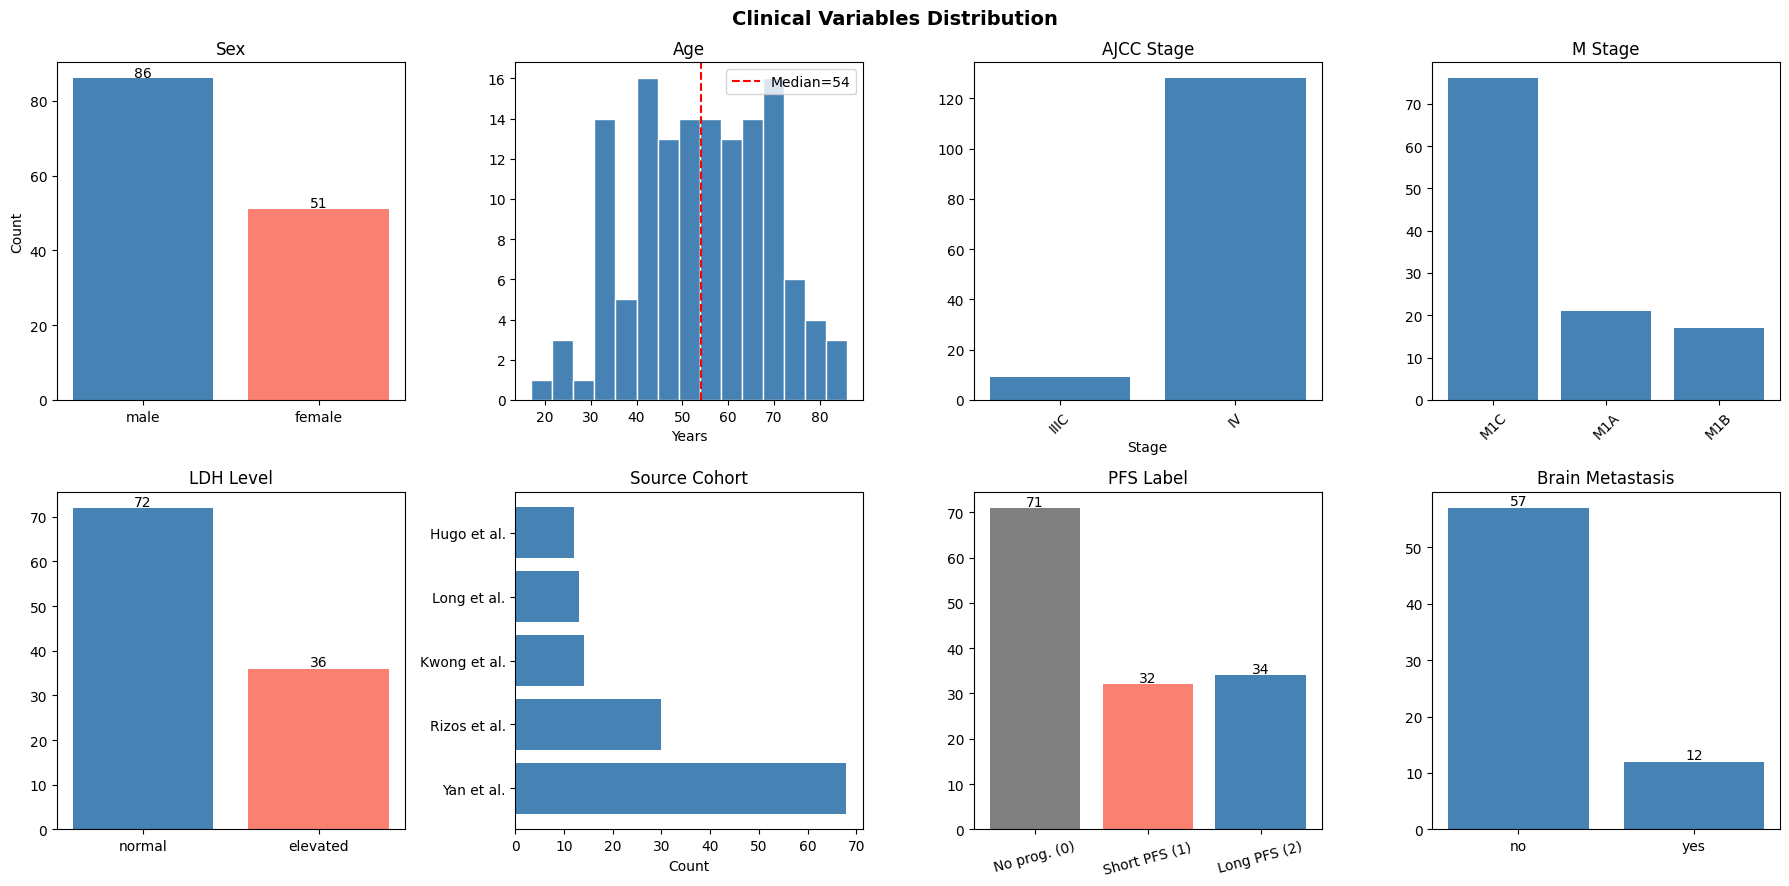

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Clinical Variables Distribution", fontsize=14, fontweight="bold")

df = clinical_gex.to_pandas()

# --- Sex ---
ax = axes[0, 0]
sex_counts = df["sex"].value_counts()
ax.bar(sex_counts.index, sex_counts.values, color=["steelblue", "salmon"])
ax.set_title("Sex")
ax.set_ylabel("Count")
for i, v in enumerate(sex_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Age ---
ax = axes[0, 1]
ax.hist(df["age"].dropna(), bins=15, color="steelblue", edgecolor="white")
ax.axvline(df["age"].median(), color="red", linestyle="--", label=f"Median={df['age'].median():.0f}")
ax.set_title("Age")
ax.set_xlabel("Years")
ax.legend()

# --- AJCC Stage ---
ax = axes[0, 2]
stage_order = ["I", "II", "IIA", "IIB", "IIC", "III", "IIIA", "IIIB", "IIIC", "IV"]
stage_counts = df["AJCC_stage"].value_counts().reindex(
    [s for s in stage_order if s in df["AJCC_stage"].values], fill_value=0
)
ax.bar(stage_counts.index, stage_counts.values, color="steelblue")
ax.set_title("AJCC Stage")
ax.set_xlabel("Stage")
ax.tick_params(axis="x", rotation=45)

# --- M Stage ---
ax = axes[0, 3]
m_counts = df["M_stage"].value_counts()
ax.bar(m_counts.index, m_counts.values, color="steelblue")
ax.set_title("M Stage")
ax.tick_params(axis="x", rotation=45)

# --- LDH ---
ax = axes[1, 0]
ldh_counts = df["LDH"].value_counts()
ax.bar(ldh_counts.index, ldh_counts.values, color=["steelblue", "salmon", "gray"][:len(ldh_counts)])
ax.set_title("LDH Level")
for i, v in enumerate(ldh_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Data source ---
ax = axes[1, 1]
src_counts = df["source"].value_counts()
ax.barh(src_counts.index, src_counts.values, color="steelblue")
ax.set_title("Source Cohort")
ax.set_xlabel("Count")

# --- PFS label ---
ax = axes[1, 2]
pfs_counts = df["pfs_label"].value_counts().sort_index()
labels = {0: "No prog. (0)", 1: "Short PFS (1)", 2: "Long PFS (2)"}
ax.bar([labels.get(i, str(i)) for i in pfs_counts.index], pfs_counts.values, color=["gray", "salmon", "steelblue"])
ax.set_title("PFS Label")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(pfs_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

# --- Brain metastasis ---
ax = axes[1, 3]
bm_counts = df["brain_metastasis"].value_counts()
ax.bar(bm_counts.index.astype(str), bm_counts.values, color="steelblue")
ax.set_title("Brain Metastasis")
for i, v in enumerate(bm_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
plt.show()

## 4. Treatment & BRAF Mutations

/var/folders/cy/vstztct90b90zhd8ssbmwpgh0000gn/T/ipykernel_20853/1745848542.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


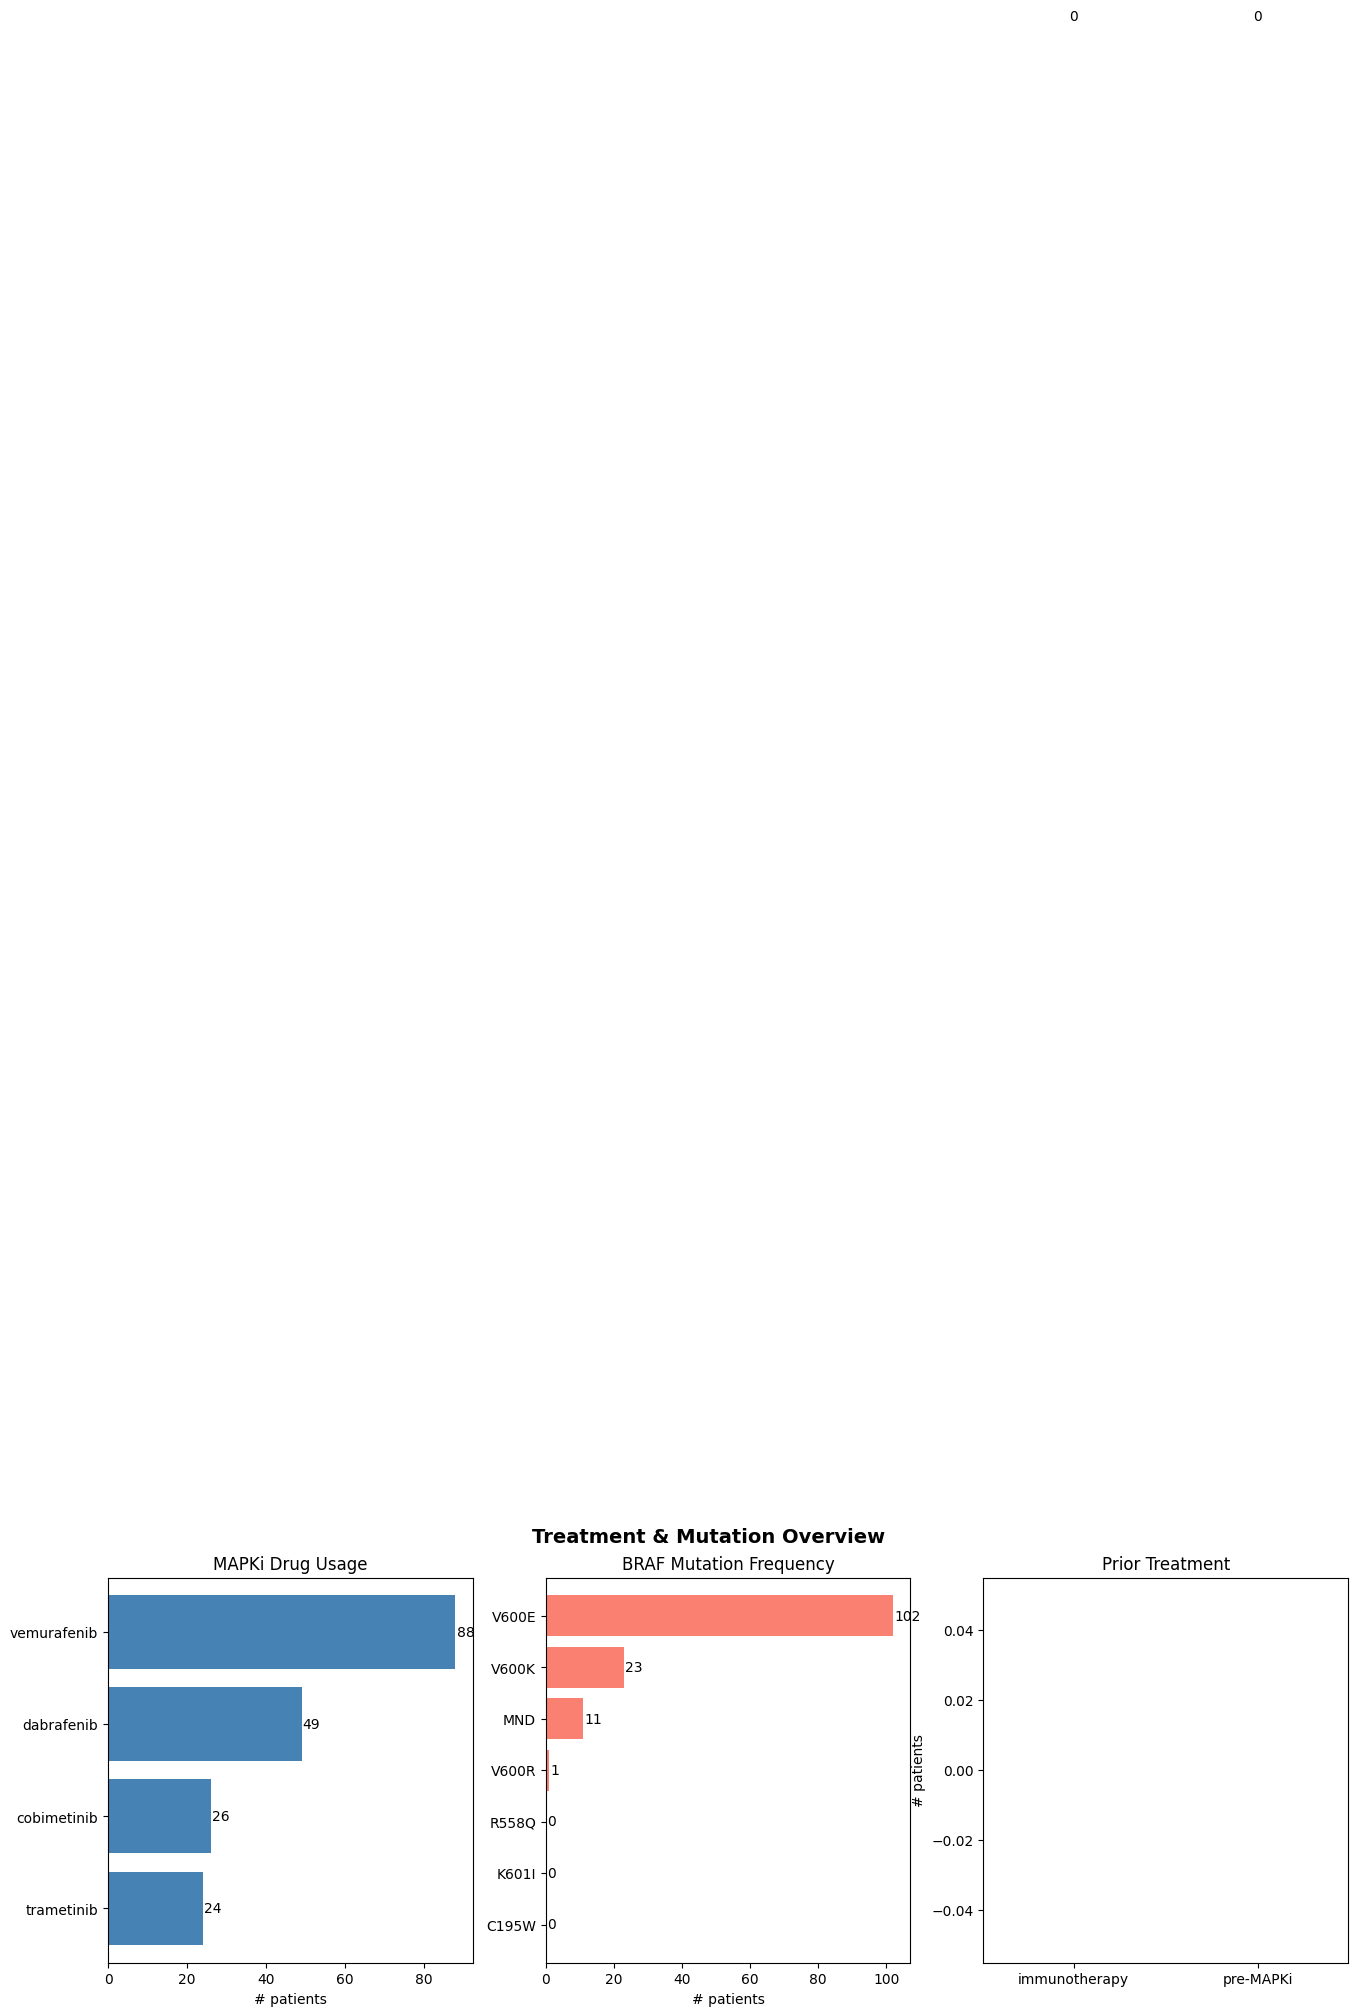

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Treatment & Mutation Overview", fontsize=14, fontweight="bold")

# --- MAPKi drugs (binary flags) ---
ax = axes[0]
drugs = ["cobimetinib", "dabrafenib", "trametinib", "vemurafenib"]
drug_counts = df[drugs].sum().sort_values(ascending=True)
ax.barh(drug_counts.index, drug_counts.values, color="steelblue")
ax.set_title("MAPKi Drug Usage")
ax.set_xlabel("# patients")
for i, v in enumerate(drug_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

# --- BRAF mutations ---
ax = axes[1]
mutations = ["C195W", "K601I", "MND", "R558Q", "V600E", "V600K", "V600R"]
mut_counts = df[mutations].sum().sort_values(ascending=True)
ax.barh(mut_counts.index, mut_counts.values, color="salmon")
ax.set_title("BRAF Mutation Frequency")
ax.set_xlabel("# patients")
for i, v in enumerate(mut_counts.values):
    ax.text(v + 0.3, i, str(int(v)), va="center")

# --- Prior treatment flags ---
ax = axes[2]
prior = {"immunotherapy": df["immunotherapy_treatment"].eq("yes").sum(),
         "pre-MAPKi":     df["pre_MAPKi_treatment"].eq("yes").sum()}
ax.bar(list(prior.keys()), list(prior.values()), color=["steelblue", "salmon"])
ax.set_title("Prior Treatment")
ax.set_ylabel("# patients")
for i, v in enumerate(prior.values()):
    ax.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
plt.show()

## 5. Gene Expression Distribution

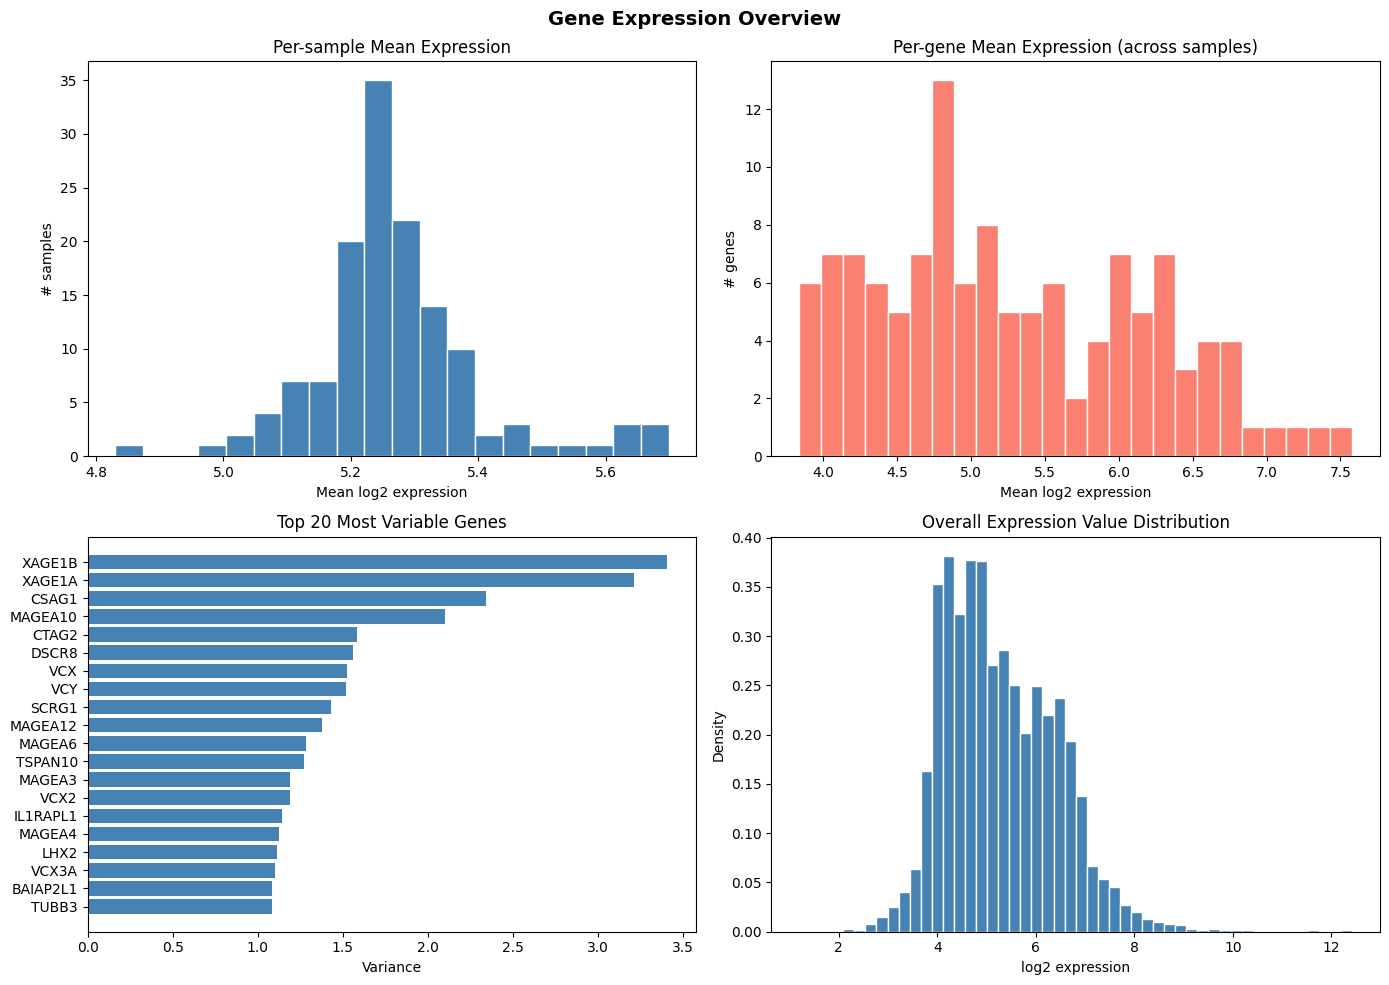


Expression range: [1.190, 12.426]
Global mean: 5.270  |  std: 1.151


In [14]:
gex = df[GEX_COLS].values  # shape (137, 122)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Gene Expression Overview", fontsize=14, fontweight="bold")

# --- Per-sample mean expression ---
ax = axes[0, 0]
sample_means = gex.mean(axis=1)
ax.hist(sample_means, bins=20, color="steelblue", edgecolor="white")
ax.set_title("Per-sample Mean Expression")
ax.set_xlabel("Mean log2 expression")
ax.set_ylabel("# samples")

# --- Per-gene mean expression ---
ax = axes[0, 1]
gene_means = gex.mean(axis=0)
ax.hist(gene_means, bins=25, color="salmon", edgecolor="white")
ax.set_title("Per-gene Mean Expression (across samples)")
ax.set_xlabel("Mean log2 expression")
ax.set_ylabel("# genes")

# --- Per-gene variance (top 20 most variable genes) ---
ax = axes[1, 0]
gene_vars = gex.var(axis=0)
top20_idx = gene_vars.argsort()[::-1][:20]
top20_genes = [GEX_COLS[i] for i in top20_idx]
top20_vars  = gene_vars[top20_idx]
ax.barh(top20_genes[::-1], top20_vars[::-1], color="steelblue")
ax.set_title("Top 20 Most Variable Genes")
ax.set_xlabel("Variance")

# --- Overall expression value distribution ---
ax = axes[1, 1]
ax.hist(gex.ravel(), bins=50, color="steelblue", edgecolor="white", density=True)
ax.set_title("Overall Expression Value Distribution")
ax.set_xlabel("log2 expression")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

print(f"\nExpression range: [{gex.min():.3f}, {gex.max():.3f}]")
print(f"Global mean: {gex.mean():.3f}  |  std: {gex.std():.3f}")

## 6. Expression by PFS Label

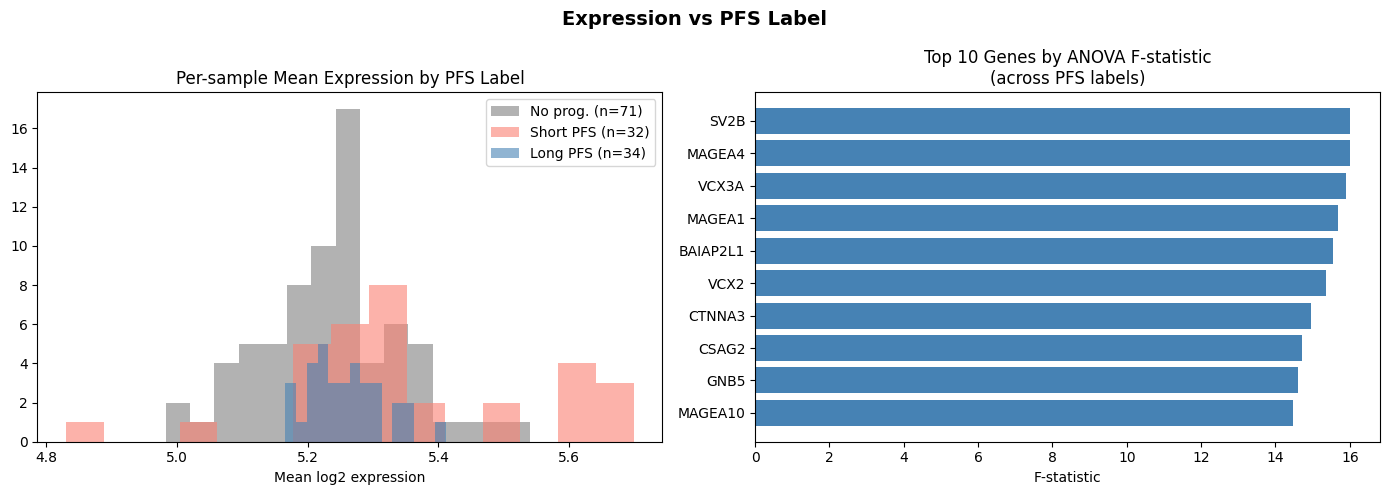

In [15]:
from scipy import stats

pfs_labels = df["pfs_label"].values
label_names = {0: "No prog.", 1: "Short PFS", 2: "Long PFS"}
colors = {0: "gray", 1: "salmon", 2: "steelblue"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Expression vs PFS Label", fontsize=14, fontweight="bold")

# --- Per-sample mean expression by PFS label ---
ax = axes[0]
for lbl in sorted(df["pfs_label"].unique()):
    mask = pfs_labels == lbl
    ax.hist(sample_means[mask], bins=15, alpha=0.6,
            label=f"{label_names[lbl]} (n={mask.sum()})", color=colors[lbl])
ax.set_title("Per-sample Mean Expression by PFS Label")
ax.set_xlabel("Mean log2 expression")
ax.legend()

# --- Top differentially expressed genes (ANOVA F-statistic) ---
ax = axes[1]
groups = [gex[pfs_labels == lbl] for lbl in sorted(df["pfs_label"].unique())]
f_stats = np.array([stats.f_oneway(*[g[:, i] for g in groups]).statistic for i in range(len(GEX_COLS))])
top10_idx = f_stats.argsort()[::-1][:10]
top10_genes = [GEX_COLS[i] for i in top10_idx]
top10_f = f_stats[top10_idx]
ax.barh(top10_genes[::-1], top10_f[::-1], color="steelblue")
ax.set_title("Top 10 Genes by ANOVA F-statistic\n(across PFS labels)")
ax.set_xlabel("F-statistic")

plt.tight_layout()
plt.show()